<a href="https://colab.research.google.com/github/sunilsinghuk/Python-Programming/blob/main/L1_TO_L5__Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lecture 1: Introduction to Data Preprocessing**
## **🔹 Why Data Preprocessing?**
Data preprocessing is a crucial step before feeding data into a machine learning model. It helps clean and prepare the raw data to improve model performance.

**🔹Why it's needed:**

1. Inconsistent formats (e.g., date formats, currency symbols).

2. Missing data can mislead models or cause errors.

3. Outliers may skew statistical analyses.

4. Categorical data needs to be converted into numerical format.

5. Scaling differences between features can negatively affect some algorithms.

**🔹 Common Data Issues**

1. Missing Values: Empty cells, NaN values.

2. Inconsistent Data: Different formats or misspellings (e.g., "NY", "New York").

3. Outliers: Abnormally high/low values that differ from most data points.

**🔹 Real-Life Example**

Sales Dataset Sample:

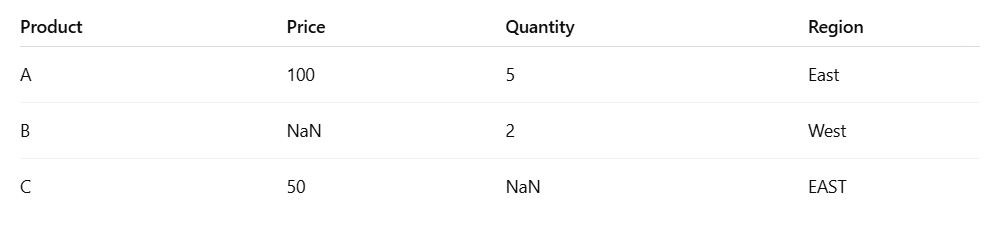

Issues:

1. Missing price and quantity.

2. Region inconsistency ("East" vs. "EAST").

In [ ]:
import pandas as pd

# Creating raw data with issues
data = {
    'Product': ['A', 'B', 'C'],
    'Price': [100, None, 50],
    'Quantity': [5, 2, None],
    'Region': ['East', 'West', 'EAST']
}

df = pd.DataFrame(data)
print(df)


  Product  Price  Quantity Region
0       A  100.0       5.0   East
1       B    NaN       2.0   West
2       C   50.0       NaN   EAST


# **📘 Lecture 2: Handling Missing Values – Part 1**
## **🔹 Detecting Missing Values**
1. isnull() → Detects NaNs.

2. notnull() → Detects non-missing values.

In [ ]:
print(df.isnull())
print(df.isnull().sum())  # Total missing in each column

   Product  Price  Quantity  Region
0    False  False     False   False
1    False   True     False   False
2    False  False      True   False
Product     0
Price       1
Quantity    1
Region      0
dtype: int64


## **🔹 Removing Missing Values: dropna()**
1. Removes rows with any NaNs (default).

2. Can also remove columns with NaNs using axis=1.

In [ ]:
df_dropped = df.dropna()
print(df_dropped)

  Product  Price  Quantity Region
0       A  100.0       5.0   East


## **🔹 Impact of Dropping Data**
1. If too many rows are dropped, you may lose valuable data.

2. Best when missing values are few or non-critical.



In [ ]:
print("Original:\n", df)
df_cleaned = df.dropna()
print("After dropna:\n", df_cleaned)

Original:
   Product  Price  Quantity Region
0       A  100.0       5.0   East
1       B    NaN       2.0   West
2       C   50.0       NaN   EAST
After dropna:
   Product  Price  Quantity Region
0       A  100.0       5.0   East


# **📘 Lecture 3: Handling Missing Values – Part 2**
**🎯 Objective**

To understand various imputation techniques used to fill missing values instead of dropping them, and how to implement them correctly using Pandas.

**What is Imputation?**

Imputation is the process of replacing missing data with substituted values so that the dataset remains usable.

Instead of deleting rows/columns (which may result in loss of information), imputation allows us to retain maximum data for training ML models.

**Why Impute Data Instead of Dropping It?**

1. Dropping data can cause data loss and bias.

2. Some algorithms can’t handle missing values.

3. Filling missing data helps maintain the structure and size of the dataset.

## **🔹 Imputation Techniques**
**1. Mean Imputation**

In [ ]:
import pandas as pd

# Sample data
data = {'Price': [25000, 27000, None, 30000, None, 28000]}
df = pd.DataFrame(data)

# Correct way to fill missing values with mean
df['Price'] = df['Price'].fillna(df['Price'].mean())
print(df)


     Price
0  25000.0
1  27000.0
2  27500.0
3  30000.0
4  27500.0
5  28000.0


**2. Median Imputation**

Used when data is skewed (less affected by outliers).

In [ ]:
df['Price'] = df['Price'].fillna(df['Price'].median())
print(df)

     Price
0  25000.0
1  27000.0
2  27500.0
3  30000.0
4  27500.0
5  28000.0


**3. Mode Imputation**

Common for categorical columns.

In [ ]:
df['Category'] = ['A', 'B', None, 'A', 'B', None]
df['Category'] = df['Category'].fillna(df['Category'].mode()[0])
print(df)

     Price Category
0  25000.0        A
1  27000.0        B
2  27500.0        A
3  30000.0        A
4  27500.0        B
5  28000.0        A


## **🔁 Forward Fill & Backward Fill**
**🔹 Forward Fill (method='ffill')**

Fills missing values with the previous value.

In [ ]:
df['Price'] = df['Price'].ffill()

**🔹 Backward Fill (method='bfill')**

Fills missing values with the next value.

In [ ]:
df['Price'] = df['Price'].bfill()

### **Hands-on Exercise**

In [ ]:
# Sample dataset
data = {'Age': [25, None, 30, None, 28], 'Salary': [50000, 60000, None, 52000, 58000]}
df = pd.DataFrame(data)

# Imputation using different methods
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Salary'] = df['Salary'].fillna(method='ffill')

print(df)

    Age   Salary
0  25.0  50000.0
1  28.0  60000.0
2  30.0  60000.0
3  28.0  52000.0
4  28.0  58000.0


<ipython-input-16-8b80d0e108b2>:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Salary'] = df['Salary'].fillna(method='ffill')


## **Conclusion**
1. Imputation is key to building robust datasets.

2. Choose the right method depending on the data distribution.

3. Always avoid chained assignments for future compatibility with Pandas.

## **Lecture 4: Data Transformation – Scaling & Normalization**
### **🎯 Objective**
Understand why scaling and normalization are important in machine learning and how to perform them using Python libraries like sklearn.preprocessing.

### **Why Scale Data?**
In machine learning, many models are sensitive to the range and distribution of feature values.

**Key Reasons:**
1. Features with different scales may dominate others (e.g., Age vs Income).

2. Algorithms like KNN, K-Means, SVM, Gradient Descent perform better when data is scaled.

3. It helps achieve faster convergence and better accuracy.

### **Types of Data Scaling Methods**
**1. Min-Max Scaling (Normalization)**

Rescales the feature into a fixed range, usually [0, 1].

**Formula:**

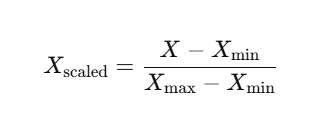


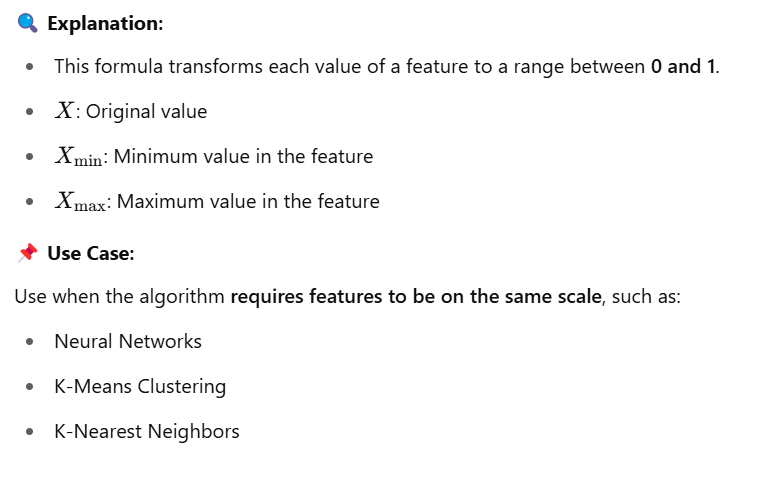

**Sensitive to outliers.**

**Code Example:**

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Sample Data
data = {'Income': [20000, 25000, 30000, 40000, 100000]}
df = pd.DataFrame(data)

# Apply Min-Max Scaling
scaler = MinMaxScaler()
df['Income_scaled'] = scaler.fit_transform(df[['Income']])

print(df)


   Income  Income_scaled
0   20000         0.0000
1   25000         0.0625
2   30000         0.1250
3   40000         0.2500
4  100000         1.0000


**2. Standardization (Z-score Normalization)**

Rescales data to have mean = 0 and standard deviation = 1.

**Formula:**

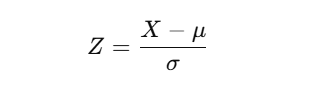

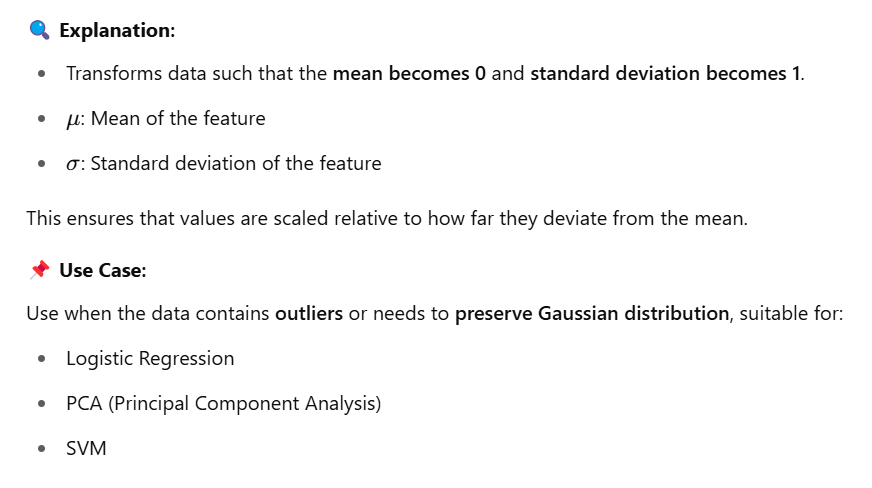

**Code Example:**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Apply Standardization
scaler = StandardScaler()
df['Income_Standardized'] = scaler.fit_transform(df[['Income']])

print(df)


   Income  Income_scaled  Income_Standardized
0   20000         0.0000            -0.786124
1   25000         0.0625            -0.615227
2   30000         0.1250            -0.444331
3   40000         0.2500            -0.102538
4  100000         1.0000             1.948220


### **When to Use Which?**
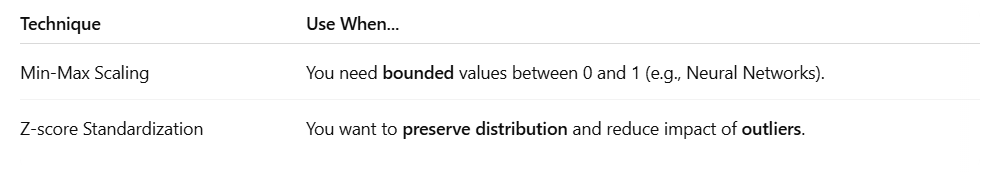


### **Hands-On Task for Students:**
1. Load a dataset (e.g., Iris or Tips).

2. Apply both Min-Max Scaling and Standardization to numerical columns.

3. Plot histograms before and after scaling.

4. Discuss changes in distribution.

### **Key Takeaways**
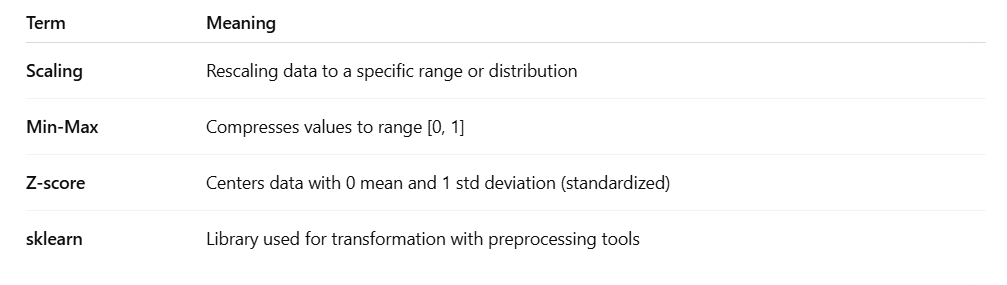


# **Lecture -5: Box Plot – Basics Explained**
A Box Plot (also known as a box-and-whisker plot) is a graphical representation used to show the distribution of a dataset and highlight outliers. It summarizes data using five key summary statistics:

## **Five Number Summary:**
1. Minimum – the smallest data point (excluding outliers)

2. First Quartile (Q1) – 25% of the data is below this point

3. Median (Q2) – the middle value of the data

4. Third Quartile (Q3) – 75% of the data is below this point

5. Maximum – the largest data point (excluding outliers)

## **Structure of a Box Plot:**
* The box represents the interquartile range (IQR = Q3 − Q1).

* The line inside the box represents the median (Q2).

* The whiskers extend to the minimum and maximum values within 1.5 * IQR.

* Points outside the whiskers are considered outliers.

## **When to Use a Box Plot:**
1. To compare distributions across categories.

2. To identify outliers in data.

3. To quickly visualize spread and skewness.


**Example in Python (using Matplotlib & Seaborn)**

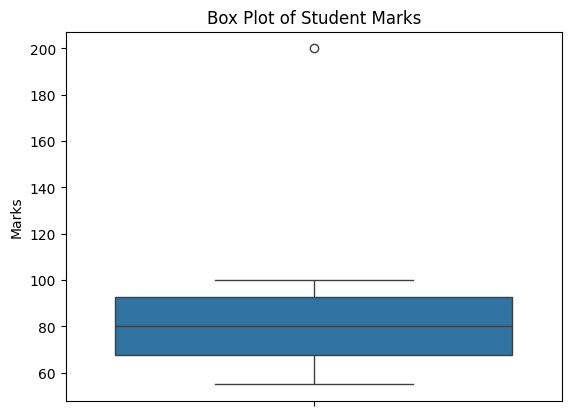

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sample data
data = {
    'Marks': [55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 200]  # Note the outlier (200)
}
df = pd.DataFrame(data)

# Box plot using seaborn
sns.boxplot(y='Marks', data=df)
plt.title('Box Plot of Student Marks')
plt.show()


## **Explanation:**
* The box shows the middle 50% of marks (from Q1 to Q3).

* The line inside the box is the median mark.

* The whiskers extend to data within 1.5×IQR.

* The dot (200) is an outlier, as it lies outside the whiskers.

# **What Are Outliers?**
An outlier is a data point that is significantly different from the rest of the data. It lies far away from other values and can skew your analysis if not handled properly.

## **Why Do Outliers Matter?**
1. Outliers can distort statistical summaries (like mean and standard deviation).

2. They might indicate:

    * Data entry errors (e.g., typing 1000 instead of 100).

    * Special cases or rare events (e.g., an unusually high sale).


## **How to Detect Outliers**
**1. Visual Methods**
    * Box Plot: Any point outside the whiskers is an outlier.

    * Scatter Plot: Dots far away from the cluster are potential outliers.

**2. Statistical Methods**

   **1. IQR (Interquartile Range) Method**

    Calculate Q1 (25th percentile) and Q3 (75th percentile)

    IQR = Q3 - Q1

**Outliers are:**

    Below Q1 - 1.5×IQR

    Above Q3 + 1.5×IQR
  

  **2. Z-Score Method**

Measures how many standard deviations a data point is from the mean.

  If |Z| > 3, it's considered an outlier.


**Example Using IQR in Python**

In [ ]:
import pandas as pd

# Sample dataset
data = {'Score': [55, 57, 58, 60, 61, 62, 64, 90, 95, 120]}
df = pd.DataFrame(data)

# Calculate IQR
Q1 = df['Score'].quantile(0.25)
Q3 = df['Score'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df['Score'] < lower_bound) | (df['Score'] > upper_bound)]
print("Outliers:\n", outliers)


Outliers:
 Empty DataFrame
Columns: [Score]
Index: []


## **How to Handle Outliers?**

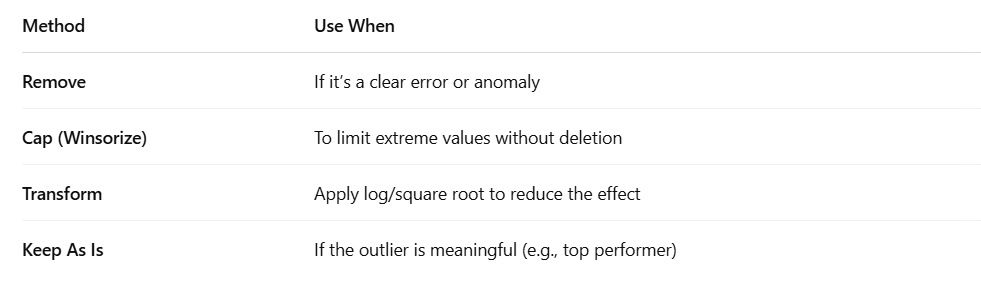